# LimeSurvey Analysis Notebook

This notebook loads and explores LimeSurvey exports.

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_theme(style='whitegrid')

In [35]:
# Update filename if needed
csv_path = 'results-survey432293.csv'
df = pd.read_csv(csv_path)

print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')
df.head()

Rows: 25, Columns: 135


,id,submitdate,lastpage,startlanguage,seed,startdate,datestamp,Q00001[SQ001],Q00001[SQ002],Q00001[SQ003],...,groupTime5717,Q00030Time,Q00031Time,Q00032Time,Q00033Time,Q00034Time,groupTime5708,Q00035Time,Q00036Time,Q00037Time
0,2,2026-03-25 11:03:14,9,en,1851706079,2026-03-25 10:44:51,2026-03-25 11:03:14,No,Yes,No,...,20.58,NaN,NaN,NaN,NaN,NaN,5.30,NaN,NaN,NaN
1,4,2026-03-25 11:06:59,9,en,663332136,2026-03-25 10:45:13,2026-03-25 11:06:59,No,Yes,No,...,36.65,NaN,NaN,NaN,NaN,NaN,64.01,NaN,NaN,NaN
2,6,2026-03-25 11:04:24,9,en,386207750,2026-03-25 10:45:17,2026-03-25 11:04:24,No,Yes,No,...,35.19,NaN,NaN,NaN,NaN,NaN,3.16,NaN,NaN,NaN
3,7,2026-03-25 11:02:06,9,en,1234118210,2026-03-25 10:45:43,2026-03-25 11:02:06,No,No,No,...,15.19,NaN,NaN,NaN,NaN,NaN,56.62,NaN,NaN,NaN
4,8,2026-03-25 11:05:12,9,en,1444895015,2026-03-25 10:46:41,2026-03-25 11:05:12,No,Yes,No,...,26.27,NaN,NaN,NaN,NaN,NaN,72.29,NaN,NaN,NaN


# Cleanup unused columns

In [36]:
# change the index to the id column

df = df.set_index("id")

In [37]:
#drop row with id 7
#df = df.drop(4)

In [38]:
# drop all columns starting with Q00007..Q00011
# (intro questions + object comprehension) no need for that

prefixes = [f"Q{i:05d}" for i in range(7, 12)]
print(prefixes)
#text field
prefixes.append("Q00026")
prefixes.append("Q00014")
prefixes.append("Q00030")


cols_to_drop = [
    col for col in df.columns
    if any(col.startswith(prefix) for prefix in prefixes)
]
print(cols_to_drop)
df = df.drop(columns=cols_to_drop)
print(f"Dropped {len(cols_to_drop)} columns")

['Q00007', 'Q00008', 'Q00009', 'Q00010', 'Q00011']
['Q00007', 'Q00008', 'Q00009', 'Q00010', 'Q00011[SQ001]', 'Q00011[SQ002]', 'Q00011[SQ003]', 'Q00011[SQ004]', 'Q00011[SQ005]', 'Q00014', 'Q00026', 'Q00030', 'Q00007Time', 'Q00008Time', 'Q00009Time', 'Q00010Time', 'Q00011Time', 'Q00014Time', 'Q00026Time', 'Q00030Time']
Dropped 20 columns


In [ ]:
# following columns need to be renamed at the exact same time 
#SQ00028[SQ004] -> Q00028[SQ002]
#SQ00028[SQ002] -> Q00028[SQ003]
#SQ00028[SQ003] -> Q00028[SQ005]
#SQ00028[SQ005] -> Q00028[SQ004]

#SQ00027[SQ006] -> Q00027[SQ002]
#SQ00027[SQ002] -> Q00027[SQ003]
#SQ00027[SQ003] -> Q00027[SQ005]
#SQ00027[SQ005] -> Q00027[SQ006]

#SQ00029[SQ004] -> Q00029[SQ002]
#SQ00029[SQ002] -> Q00029[SQ003]
#SQ00029[SQ003] -> Q00029[SQ005]
#SQ00029[SQ005] -> Q00029[SQ004]

df = df.rename(columns={
    "SQ00028[SQ004]": "Q00028[SQ002]",
    "SQ00028[SQ002]": "Q00028[SQ003]",
    "SQ00028[SQ003]": "Q00028[SQ005]",
    "SQ00028[SQ005]": "Q00028[SQ004]",
    "SQ00027[SQ006]": "Q00027[SQ002]",
    "SQ00027[SQ002]": "Q00027[SQ003]",
    "SQ00027[SQ003]": "Q00027[SQ005]",
    "SQ00027[SQ005]": "Q00027[SQ006]",
    "SQ00029[SQ004]": "Q00029[SQ002]",
    "SQ00029[SQ002]": "Q00029[SQ003]",
    "SQ00029[SQ003]": "Q00029[SQ005]",
    "SQ00029[SQ005]": "Q00029[SQ004]",
})




# Creating Subsets


Expertise Level Description
Aviation Domain Expert Active or former Air Traffic Controller
Aviation Semi-Domain Expert Person working or researching on ATM in general
Aviation Layperson Any other person without sufficient knowledge about
ATM or ATC

Expertise Level Description
AI Domain Expert Studied or researches AI-relevant subjects and has
knowledge about XAI and RL
AI Semi-Domain Expert Person having an understanding of AI but not about
XAI
AI Layperson Any other person without sufficient knowledge about


In [40]:

atc_knowledge_levels = [
    "Working Knowledge: I understand ATC procedures and operational context in depth (e.g., work in ATM, studied it formally)",
    "Expert: I have direct operational experience as a controller or deep professional ATC expertise",
    "Conceptual Understanding: I understand key ATC concepts, terminology, and challenges without operational experience",
]

mask_domain = df["Q00001[SQ001]"].eq("Yes")  # active/former ATC
mask_semibase = df["Q00001[SQ002]"].eq("Yes")  # ATM-related work/research
mask_knowledge = df["Q00002"].isin(atc_knowledge_levels)

# Make groups disjoint:
mask_semi = (~mask_domain) & mask_semibase & mask_knowledge
mask_layman = ~(mask_domain | mask_semi)

AviationDomainExperts = df[mask_domain]
AviationSemiDomainExperts = df[mask_semi]
AviationLayman = df[mask_layman]

# Optional check:
print(len(AviationDomainExperts), len(AviationSemiDomainExperts), len(AviationLayman), len(df))


0 6 19 25


In [41]:


ml_expert_knowledge_levels = [
    "Technical: I understand core mechanics (e.g., gradient descent, loss functions, model architectures) and can work with them confidently",
    "Expert: I have deep theoretical and practical ML knowledge, including mathematical foundations, and can critically analyze or develop models"
]
ml_semi_knowledge_levels = [
    "Applied: I can use ML tools/libraries without fully understanding the math",
    "Technical: I understand core mechanics (e.g., gradient descent, loss functions, model architectures) and can work with them confidently",
    "Expert: I have deep theoretical and practical ML knowledge, including mathematical foundations, and can critically analyze or develop models"
]

mask_ai_domain_experts = (df["Q00001[SQ004]"].eq("Yes") | df["Q00001[SQ003]"].eq("Yes"))  # Student or aiml reaearch professional
mask_rl_xrl = (df["Q00004"].eq("Yes") & df["Q00005"].eq("Yes")) # knowledge a bout XRL RL
mask_not_xai = df["Q00005"].eq("No")

mask_expert_knowledge = df["Q00003"].isin(ml_expert_knowledge_levels)
mask_semi_knowledge = df["Q00003"].isin(ml_semi_knowledge_levels)

mask_expert = (mask_ai_domain_experts & mask_rl_xrl & mask_expert_knowledge)
mask_semi = (~mask_expert & mask_semi_knowledge)
mask_layman = ~(mask_expert | mask_semi)

AiDomainExperts = df[mask_expert]
AiSemiDomainExperts = df[mask_semi]
AiLayman= df[mask_layman]

print(len(AiDomainExperts), len(AiSemiDomainExperts), len(AiLayman), len(df))


8 11 6 25


In [42]:
groups = {
    "All Participants": df,
    "AI Domain Experts": AiDomainExperts,
    "AI Semi-Domain Experts": AiSemiDomainExperts,
    "AI Layman": AiLayman,
    "Aviation Domain Experts": AviationDomainExperts,
    "Aviation Semi-Domain Experts": AviationSemiDomainExperts,
    "Aviation Layman": AviationLayman,
}

# go over all groups if len == 0 remove them from the groups dict
groups = {k: v for k, v in groups.items() if len(v) > 0}
print("Groups after filtering empty ones:", list(groups.keys()))

Groups after filtering empty ones: ['All Participants', 'AI Domain Experts', 'AI Semi-Domain Experts', 'AI Layman', 'Aviation Semi-Domain Experts', 'Aviation Layman']


In [43]:
# Question-code pairs for pre/post comparison

mental_model_pairs = {
    "saliency_safe_state": {"pre": "Q00012", "post": "Q00022"},
    "saliency_conflict_state": {"pre": "Q00013", "post": "Q00021"},
    "moe": {"pre": "Q00015", "post": "Q00024"},
    "action_heatmaps": {"pre": "Q00016", "post": "Q00025"},
}

explanation_trust_pairs = {
    "trust_item_1": {"pre": "Q00017", "post": "Q00031"},
    "trust_item_2": {"pre": "Q00018", "post": "Q00032"},
    "trust_item_3": {"pre": "Q00019", "post": "Q00033"},
    "trust_item_4": {"pre": "Q00020", "post": "Q00034"},
}

question_pairs = {
    "mental_models": mental_model_pairs,
    "explanation_trust": explanation_trust_pairs,
}

likert_scale = {"I agree strongly": 2,
                "I agree somewhat": 1,
                "I’m neutral about it": 0,
                "I disagree somewhat": -1,
                "I disagree strongly": -2
                
                }

question_pairs

{'mental_models': {'saliency_safe_state': {'pre': 'Q00012', 'post': 'Q00022'},
  'saliency_conflict_state': {'pre': 'Q00013', 'post': 'Q00021'},
  'moe': {'pre': 'Q00015', 'post': 'Q00024'},
  'action_heatmaps': {'pre': 'Q00016', 'post': 'Q00025'}},
 'explanation_trust': {'trust_item_1': {'pre': 'Q00017', 'post': 'Q00031'},
  'trust_item_2': {'pre': 'Q00018', 'post': 'Q00032'},
  'trust_item_3': {'pre': 'Q00019', 'post': 'Q00033'},
  'trust_item_4': {'pre': 'Q00020', 'post': 'Q00034'}}}

In [44]:
def calculate_cronbach_alpha(df):
    """Calculates Cronbach's alpha for a dataframe of items."""
    k = df.shape[1]
    if k < 2:
        return np.nan
        
    item_variances = df.var(ddof=1)
    total_variance = df.sum(axis=1).var(ddof=1)
    
    if total_variance == 0:
        print("Total variance is zero, Cronbach's alpha is undefined. Returning 0.")
        return 0.0
        
    alpha = (k / (k - 1)) * (1 - (item_variances.sum() / total_variance))
    return alpha

# Pre post trust comparison


In [45]:
def compare_pre_post(df, question_pairs, likert_scale, section="explanation_trust"):
    pairs = question_pairs[section]
    reverse_cols = ["Q00018","Q00032"] # Need to reverse these values since its a negative statement "I am wary of .."
    print(pairs)
    rows = []
    per_person = pd.DataFrame(index=df.index)
    for item, cols in pairs.items():
        pre = df[cols["pre"]].map(likert_scale)
        post = df[cols["post"]].map(likert_scale)
        
        if cols["pre"] in reverse_cols:
            pre = pre * -1
        if cols["post"] in reverse_cols:
            post = post * -1
        
        delta = post - pre

        per_person[f"{item}_pre"] = pre
        per_person[f"{item}_post"] = post
        per_person[f"{item}_delta"] = delta

        rows.append({
            "item": item,
            "n_paired": int((pre.notna() & post.notna()).sum()),
            "pre_mean": pre.mean(),
            "post_mean": post.mean(),
            "delta_mean": delta.mean(),
        })

    item_summary = pd.DataFrame(rows).set_index("item")

    pre_cols = [c for c in per_person.columns if c.endswith("_pre")]
    post_cols = [c for c in per_person.columns if c.endswith("_post")]
    delta_cols = [c for c in per_person.columns if c.endswith("_delta") and c != "overall_delta"]

    
    per_person["overall_pre"] = per_person[pre_cols].mean(axis=1, skipna=True)
    per_person["overall_post"] = per_person[post_cols].mean(axis=1, skipna=True)
    per_person["overall_delta"] = per_person["overall_post"] - per_person["overall_pre"]

    overall_summary = pd.Series({
        "n_people_with_any_pair": int(per_person["overall_delta"].notna().sum()),
        "overall_pre_mean": per_person["overall_pre"].mean(),
        "overall_post_mean": per_person["overall_post"].mean(),
        "overall_delta_mean": per_person["overall_delta"].mean(),
        "cronbach_alpha_pre": calculate_cronbach_alpha(per_person[pre_cols]),
        "cronbach_alpha_post": calculate_cronbach_alpha(per_person[post_cols]),
        "cronbach_alpha_delta": calculate_cronbach_alpha(per_person[delta_cols]),
    })

    return item_summary, overall_summary, per_person


from IPython.display import display, Markdown


all_results = {}

for group_name, gdf in groups.items():
    item_summary, overall_summary, scores = compare_pre_post(
        gdf, question_pairs, likert_scale, section="explanation_trust"
    )
    all_results[group_name] = {
        "item_summary": item_summary,
        "overall_summary": overall_summary,
        "scores": scores,
    }

    display(Markdown(f"### {group_name} (n={len(gdf)})"))
    display(item_summary)
    display(overall_summary)

{'trust_item_1': {'pre': 'Q00017', 'post': 'Q00031'}, 'trust_item_2': {'pre': 'Q00018', 'post': 'Q00032'}, 'trust_item_3': {'pre': 'Q00019', 'post': 'Q00033'}, 'trust_item_4': {'pre': 'Q00020', 'post': 'Q00034'}}


### All Participants (n=25)

,n_paired,pre_mean,post_mean,delta_mean
item,,,,
trust_item_1,25,0.28,0.80,0.52
trust_item_2,25,-0.44,-0.32,0.12
trust_item_3,25,-0.08,0.20,0.28
trust_item_4,25,0.20,0.36,0.16


n_people_with_any_pair    25.000000
overall_pre_mean          -0.010000
overall_post_mean          0.260000
overall_delta_mean         0.270000
cronbach_alpha_pre         0.755037
cronbach_alpha_post        0.668903
cronbach_alpha_delta       0.723580
dtype: float64

{'trust_item_1': {'pre': 'Q00017', 'post': 'Q00031'}, 'trust_item_2': {'pre': 'Q00018', 'post': 'Q00032'}, 'trust_item_3': {'pre': 'Q00019', 'post': 'Q00033'}, 'trust_item_4': {'pre': 'Q00020', 'post': 'Q00034'}}


...

n_people_with_any_pair    6.000000
overall_pre_mean          0.500000
overall_post_mean         0.250000
overall_delta_mean       -0.250000
cronbach_alpha_pre        0.641975
cronbach_alpha_post       0.412698
cronbach_alpha_delta      0.878788
dtype: float64

{'trust_item_1': {'pre': 'Q00017', 'post': 'Q00031'}, 'trust_item_2': {'pre': 'Q00018', 'post': 'Q00032'}, 'trust_item_3': {'pre': 'Q00019', 'post': 'Q00033'}, 'trust_item_4': {'pre': 'Q00020', 'post': 'Q00034'}}


### Aviation Layman (n=19)

,n_paired,pre_mean,post_mean,delta_mean
item,,,,
trust_item_1,19,0.052632,0.789474,0.736842
trust_item_2,19,-0.578947,-0.368421,0.210526
trust_item_3,19,-0.315789,0.210526,0.526316
trust_item_4,19,0.157895,0.421053,0.263158


n_people_with_any_pair    19.000000
overall_pre_mean          -0.171053
overall_post_mean          0.263158
overall_delta_mean         0.434211
cronbach_alpha_pre         0.746632
cronbach_alpha_post        0.725253
cronbach_alpha_delta       0.519797
dtype: float64

# Satisfaction Comparison

In [82]:
import pandas as pd
import numpy as np
from IPython.display import display, Markdown

questions = {
    "object_based_saliency": "Q00027",
    "action_heatmap": "Q00028",
    "moe_explanation": "Q00029",
}

subquestions = [f"SQ{i:03d}" for i in range(1, 7)]
#drop SQ005 since it lowers cronbach alpha for some groups
subquestions.remove("SQ005")
#subquestions.remove("SQ001")
#subquestions.remove("SQ006")


def analyze_explanation_satisfaction(df, questions, subquestions, likert_scale):
    results = {}

    for q_name, q_code in questions.items():
        satisfaction_cols = [f"{q_code}[{sq}]" for sq in subquestions]
        existing_cols = [c for c in satisfaction_cols if c in df.columns]

        if not existing_cols:
            results[q_name] = {
                "subquestion_table": pd.DataFrame(
                    columns=["correlation_to_mean", "mean_subquestion", "variance_subquestion"]
                ),
                "overall_mean": np.nan,
                "overall_median": np.nan,
                "n_responses": 0,
                "cronbach_alpha": np.nan,
            }
            continue

        # Map Likert text to numeric scores
        satisfaction_data = df[existing_cols].apply(lambda col: col.map(likert_scale.get))

        # Calculate Cronbach's alpha before adding aggregate columns
        alpha = calculate_cronbach_alpha(satisfaction_data[existing_cols])

        # Per-person average score for this explanation
        mean_col = f"{q_name}_mean"
        satisfaction_data[mean_col] = satisfaction_data[existing_cols].mean(axis=1, skipna=True)

        # Build one compact table per explanation
        subquestion_table = pd.DataFrame(index=existing_cols)
        subquestion_table["correlation_to_mean"] = [
            satisfaction_data[col].corr(satisfaction_data[mean_col]) for col in existing_cols
        ]
        subquestion_table["mean_subquestion"] = satisfaction_data[existing_cols].mean(axis=0)
        subquestion_table["variance_subquestion"] = satisfaction_data[existing_cols].var(axis=0, ddof=1)

        # cleaner row labels: SQ001, SQ002, ...
        subquestion_table.index = [col.split("[")[-1].rstrip("]") for col in subquestion_table.index]
        subquestion_table.index.name = "subquestion"

        results[q_name] = {
            "subquestion_table": subquestion_table.sort_index(),
            "overall_mean": satisfaction_data[mean_col].mean(),
            "overall_median": satisfaction_data[mean_col].median(),
            "n_responses": int(satisfaction_data[mean_col].notna().sum()),
            "cronbach_alpha": alpha,
        }

    return results

# Run and display results for each group
for group_name, gdf in groups.items():
    display(Markdown(f"## Explanation satisfaction — {group_name} (n={len(gdf)})"))

    satisfaction_results = analyze_explanation_satisfaction(gdf, questions, subquestions, likert_scale)

    for q_name, q_results in satisfaction_results.items():
        display(Markdown(f"### {q_name}"))

        summary_metrics = pd.Series({
            "overall_mean": q_results["overall_mean"],
            "overall_median": q_results["overall_median"],
            "n_responses": q_results["n_responses"],
            "cronbach_alpha": q_results["cronbach_alpha"],
        })
        display(summary_metrics.round(2))

        display(
            q_results["subquestion_table"].round(2)
        )

## Explanation satisfaction — All Participants (n=25)

### object_based_saliency

overall_mean       0.57
overall_median     0.80
n_responses       25.00
cronbach_alpha     0.80
dtype: float64

,correlation_to_mean,mean_subquestion,variance_subquestion
subquestion,,,
SQ001,0.38,1.16,0.64
SQ002,0.80,0.48,1.26
SQ003,0.86,0.24,1.36
SQ004,0.83,0.08,1.66
SQ006,0.79,0.88,0.94


### action_heatmap

...

overall_mean       0.65
overall_median     0.60
n_responses       19.00
cronbach_alpha     0.74
dtype: float64

,correlation_to_mean,mean_subquestion,variance_subquestion
subquestion,,,
SQ001,0.57,1.05,0.61
SQ002,0.75,0.63,1.02
SQ003,0.83,0.16,1.36
SQ004,0.69,0.95,0.94
SQ006,0.63,0.47,1.04


### moe_explanation

overall_mean       0.57
overall_median     0.40
n_responses       19.00
cronbach_alpha     0.89
dtype: float64

,correlation_to_mean,mean_subquestion,variance_subquestion
subquestion,,,
SQ001,0.80,1.11,1.21
SQ002,0.91,0.42,2.37
SQ003,0.79,0.42,2.04
SQ004,0.76,0.74,1.20
SQ006,0.91,0.16,1.70


Write that the alpha is generall high enough to justify the mean as a measure central tendency. Also interestingly for some explanations the alpha is higher.

# pre post mental model questions

Starting with the post mental model question since this can be easier interpreted since there is a clear right answer. The pre mental model question is more difficult to interpret since there is no clear right answer and the question is more about the confidence of the participants in their mental model. Also comparing pre with post mental models are tricky for some questions.

In [47]:
question_pairs["mental_models"]

{'saliency_safe_state': {'pre': 'Q00012', 'post': 'Q00022'},
 'saliency_conflict_state': {'pre': 'Q00013', 'post': 'Q00021'},
 'moe': {'pre': 'Q00015', 'post': 'Q00024'},
 'action_heatmaps': {'pre': 'Q00016', 'post': 'Q00025'}}

## post correctness of answers

### Saliency safe state

In [48]:
# for the saliency safe state the correct answer for all subquestions SQ001 to S005 is No influence

def check_saliency_safe_state(df, question_code, subquestions):
    correct_answer = "No influence"
    results = {}

    cols = [f"{question_code}[{sq}]" for sq in subquestions]
    existing_cols = [c for c in cols if c in df.columns]

    for sq in subquestions:
        col_name = f"{question_code}[{sq}]"
        if col_name in df.columns:
            counts = df[col_name].value_counts(dropna=False)
            total_responses = counts.sum()
            correct_count = counts.get(correct_answer, 0)
            accuracy = correct_count / total_responses if total_responses > 0 else np.nan

            results[sq] = {
                "total_responses": total_responses,
                "correct_count": correct_count,
                "accuracy": accuracy
            }
        else:
            results[sq] = {
                "total_responses": 0,
                "correct_count": 0,
                "accuracy": np.nan
            }

    per_sq_df = pd.DataFrame(results).T

    if existing_cols:
        all_no_influence = df[existing_cols].eq(correct_answer).all(axis=1)
        n_all_no_influence = int(all_no_influence.sum())
        pct_all_no_influence = (n_all_no_influence / len(df) * 100) if len(df) > 0 else np.nan
    else:
        n_all_no_influence = 0
        pct_all_no_influence = np.nan

    overall = pd.Series({
        "n_selected_no_influence_all_subquestions": n_all_no_influence,
        "percentage_selected_no_influence_all_subquestions": pct_all_no_influence
    })

    return per_sq_df, overall

for group_name, gdf in groups.items():
    print(f"Analyzing Saliency Safe State for group: {group_name} (n={len(gdf)})")
    subquestions = [f"SQ{i:03d}" for i in range(1, 6)]
    saliency_safe_state_results, saliency_safe_state_overall = check_saliency_safe_state(
        gdf,
        question_pairs["mental_models"]["saliency_safe_state"]["post"],
        subquestions
    )

    display(Markdown("### Saliency Safe State - Accuracy of 'No influence' Response"))
    display(saliency_safe_state_results)
    display(saliency_safe_state_overall)

Analyzing Saliency Safe State for group: All Participants (n=25)


### Saliency Safe State - Accuracy of 'No influence' Response

,total_responses,correct_count,accuracy
SQ001,25.0,17.0,0.68
SQ002,25.0,20.0,0.80
SQ003,25.0,19.0,0.76
SQ004,25.0,25.0,1.00
SQ005,25.0,24.0,0.96


n_selected_no_influence_all_subquestions             14.0
percentage_selected_no_influence_all_subquestions    56.0
dtype: float64

Analyzing Saliency Safe State for group: AI Domain Experts (n=8)


...

n_selected_no_influence_all_subquestions              2.000000
percentage_selected_no_influence_all_subquestions    33.333333
dtype: float64

Analyzing Saliency Safe State for group: Aviation Layman (n=19)


### Saliency Safe State - Accuracy of 'No influence' Response

,total_responses,correct_count,accuracy
SQ001,19.0,13.0,0.684211
SQ002,19.0,16.0,0.842105
SQ003,19.0,15.0,0.789474
SQ004,19.0,19.0,1.000000
SQ005,19.0,18.0,0.947368


n_selected_no_influence_all_subquestions             12.000000
percentage_selected_no_influence_all_subquestions    63.157895
dtype: float64

### Saliency conflicting state

In [49]:
def check_saliency_conflict_state(df, question_code, subquestions):
    correct_answer_pairs = {
        "SQ001": ["Strong influence to turn left"],  # Aircraft 1
        "SQ002": ["Weak influence to turn left", "Strong influence to turn left"],  # Aircraft 2
        "SQ003": ["No influence"],  # Aircraft 5
    }
    results = {}

    for sq in subquestions:
        col_name = f"{question_code}[{sq}]"
        if col_name in df.columns:
            counts = df[col_name].value_counts(dropna=False)
            total_responses = counts.sum()
            correct_answers = correct_answer_pairs.get(sq, [])
            correct_count = sum(counts.get(ans, 0) for ans in correct_answers)
            accuracy = correct_count / total_responses if total_responses > 0 else np.nan

            results[sq] = {
                "total_responses": total_responses,
                "correct_count": correct_count,
                "accuracy": accuracy,
            }
        else:
            results[sq] = {
                "total_responses": 0,
                "correct_count": 0,
                "accuracy": np.nan,
            }

    per_sq_df = pd.DataFrame(results).T

    existing_cols = [f"{question_code}[{sq}]" for sq in subquestions if f"{question_code}[{sq}]" in df.columns]
    if existing_cols:
        all_correct = pd.Series(True, index=df.index)
        for sq in subquestions:
            col_name = f"{question_code}[{sq}]"
            if col_name in df.columns:
                all_correct &= df[col_name].isin(correct_answer_pairs.get(sq, []))

        n_all_correct = int(all_correct.sum())
        pct_all_correct = (n_all_correct / len(df) * 100) if len(df) > 0 else np.nan
    else:
        n_all_correct = 0
        pct_all_correct = np.nan

    per_sq_df.loc["ALL_SUBQUESTIONS", "total_responses"] = len(df)
    per_sq_df.loc["ALL_SUBQUESTIONS", "correct_count"] = n_all_correct
    per_sq_df.loc["ALL_SUBQUESTIONS", "accuracy"] = n_all_correct / len(df) if len(df) > 0 else np.nan
    per_sq_df.loc["ALL_SUBQUESTIONS", "pct_all_subquestions_correct"] = pct_all_correct

    return per_sq_df

for group_name, gdf in groups.items():
    print(f"Analyzing Saliency Conflict State for group: {group_name} (n={len(gdf)})")
    subquestions_conflict = [f"SQ{i:03d}" for i in range(1, 4)]
    saliency_conflict_state_results = check_saliency_conflict_state(gdf, question_pairs["mental_models"]["saliency_conflict_state"]["post"], subquestions_conflict)
    display(Markdown("### Saliency Conflict State - Accuracy of Correct Responses"))

    display(saliency_conflict_state_results)

Analyzing Saliency Conflict State for group: All Participants (n=25)


### Saliency Conflict State - Accuracy of Correct Responses

,total_responses,correct_count,accuracy,pct_all_subquestions_correct
SQ001,25.0,22.0,0.88,NaN
SQ002,25.0,15.0,0.60,NaN
SQ003,25.0,25.0,1.00,NaN
ALL_SUBQUESTIONS,25.0,14.0,0.56,56.0


Analyzing Saliency Conflict State for group: AI Domain Experts (n=8)


### Saliency Conflict State - Accuracy of Correct Responses

...

### Saliency Conflict State - Accuracy of Correct Responses

,total_responses,correct_count,accuracy,pct_all_subquestions_correct
SQ001,6.0,5.0,0.833333,NaN
SQ002,6.0,3.0,0.500000,NaN
SQ003,6.0,6.0,1.000000,NaN
ALL_SUBQUESTIONS,6.0,3.0,0.500000,50.0


Analyzing Saliency Conflict State for group: Aviation Layman (n=19)


### Saliency Conflict State - Accuracy of Correct Responses

,total_responses,correct_count,accuracy,pct_all_subquestions_correct
SQ001,19.0,17.0,0.894737,NaN
SQ002,19.0,12.0,0.631579,NaN
SQ003,19.0,19.0,1.000000,NaN
ALL_SUBQUESTIONS,19.0,11.0,0.578947,57.894737


In [50]:
#print(df["Q00021[SQ001]"])

### Moe post

In [51]:
# Subquestions SQ001 to S003 
# correct answers are: SQ001 Controlling , SQ002 Evading, SQ003 Both equally

def check_moe_correct(df,question_code, subquestions):
    correct_answer_pairs = {
        "SQ001": ["Controlling"], 
        "SQ002": ["Evading"],
        "SQ003": ["Both equally"],
    }
    results = {}
    
    for sq in subquestions:
        col_name = f"{question_code}[{sq}]"
        if col_name in df.columns:
            counts = df[col_name].value_counts(dropna=False)
            total_responses = counts.sum()
            # Get correct answers for this subquestion
            correct_answers = correct_answer_pairs.get(sq, [])
            # Sum counts for all correct answers
            correct_count = sum(counts.get(ans, 0) for ans in correct_answers)
            accuracy = correct_count / total_responses if total_responses > 0 else np.nan
            
            results[sq] = {
                "total_responses": total_responses,
                "correct_count": correct_count,
                "accuracy": accuracy,
            }
        else:
            results[sq] = {
                "total_responses": 0,
                "correct_count": 0,
                "accuracy": np.nan
            }
    
    # Check all 3 correct
    sq_cols = [f"{question_code}[{sq}]" for sq in subquestions]
    existing_cols = [c for c in sq_cols if c in df.columns]
    
    if existing_cols:
        all_correct = pd.Series(True, index=df.index)
        for sq in subquestions:
            col_name = f"{question_code}[{sq}]"
            if col_name in df.columns:
                all_correct &= df[col_name].isin(correct_answer_pairs.get(sq, []))
        
        n_all_correct = int(all_correct.sum())
        pct_all_correct = (n_all_correct / len(df) * 100) if len(df) > 0 else np.nan
        
        results["ALL_SUBQUESTIONS"] = {
            "total_responses": len(df),
            "correct_count": n_all_correct,
            "accuracy": n_all_correct / len(df) if len(df) > 0 else np.nan,
            "percentage_all_correct": pct_all_correct
        }
    
    return pd.DataFrame(results).T

for group_name, gdf in groups.items():
    print(f"Analyzing MOE for group: {group_name} (n={len(gdf)})")

    moe_post_results = check_moe_correct(gdf, question_pairs["mental_models"]["moe"]["post"], ["SQ001", "SQ002", "SQ003"])
    display(Markdown("### MOE Post - Accuracy of Correct Responses"))
    display(moe_post_results)

Analyzing MOE for group: All Participants (n=25)


### MOE Post - Accuracy of Correct Responses

,total_responses,correct_count,accuracy,percentage_all_correct
SQ001,25.0,23.0,0.92,NaN
SQ002,25.0,23.0,0.92,NaN
SQ003,25.0,20.0,0.80,NaN
ALL_SUBQUESTIONS,25.0,19.0,0.76,76.0


Analyzing MOE for group: AI Domain Experts (n=8)


### MOE Post - Accuracy of Correct Responses

...

### MOE Post - Accuracy of Correct Responses

,total_responses,correct_count,accuracy,percentage_all_correct
SQ001,6.0,6.0,1.000000,NaN
SQ002,6.0,5.0,0.833333,NaN
SQ003,6.0,4.0,0.666667,NaN
ALL_SUBQUESTIONS,6.0,3.0,0.500000,50.0


Analyzing MOE for group: Aviation Layman (n=19)


### MOE Post - Accuracy of Correct Responses

,total_responses,correct_count,accuracy,percentage_all_correct
SQ001,19.0,17.0,0.894737,NaN
SQ002,19.0,18.0,0.947368,NaN
SQ003,19.0,16.0,0.842105,NaN
ALL_SUBQUESTIONS,19.0,16.0,0.842105,84.210526


In [52]:
print(df[question_pairs["mental_models"]["moe"]["post"]+"[SQ003]"])

id
2      Both equally
4       Controlling
6     I cannot tell
7     I cannot tell
8      Both equally
12     Both equally
20      Controlling
21     Both equally
24     Both equally
26     Both equally
27      Controlling
34     Both equally
35     Both equally
36     Both equally
38     Both equally
39     Both equally
40     Both equally
44     Both equally
51     Both equally
52     Both equally
53     Both equally
54     Both equally
55     Both equally
56     Both equally
57     Both equally
Name: Q00024[SQ003], dtype: str


### Safe state vs background agreement

In [53]:
# question code == Q00023 SQ001 (safe state) and SQ002 (background)
# used likert_scale there for mapping can be from -2 to 2 from strongly disagree to strongly agree
# for each subquestion this score will be calculated by its own in the end we get 2 agreement scores for each SQ
def check_safe_state_background_agreement(df, question_code, subquestions, likert_scale):
    results = {}

    for sq in subquestions:
        col_name = f"{question_code}[{sq}]"
        if col_name in df.columns:
            mapped_responses = df[col_name].map(likert_scale)
            results[sq] = {
                "n_responses": int(mapped_responses.notna().sum()),
                "mean_agreement": mapped_responses.mean(),
                "variance_agreement": mapped_responses.var()
            }
        else:
            results[sq] = {
                "n_responses": 0,
                "mean_agreement": np.nan
            }

    return pd.DataFrame(results).T


# Q00023 uses: Strongly Disagree, Disagree, Neutral, Agree, Strongly Agree
likert_scale2 = {
    "Strongly Disagree": -2,
    "Disagree": -1,
    "Neutral": 0,
    "Agree": 1,
    "Strongly Agree": 2,
}

for group_name, gdf in groups.items():
    print(f"Analyzing Safe State vs Background Agreement for group: {group_name} (n={len(gdf)})")

    subquestions_agreement = [f"SQ{i:03d}" for i in range(1, 3)]
    agreement_results = check_safe_state_background_agreement(
        gdf, "Q00023", subquestions_agreement, likert_scale2
    )

    display(Markdown("### Safe State vs Background Agreement"))
    display(agreement_results)


Analyzing Safe State vs Background Agreement for group: All Participants (n=25)


### Safe State vs Background Agreement

,n_responses,mean_agreement,variance_agreement
SQ001,25.0,0.56,1.590000
SQ002,25.0,1.04,1.206667


Analyzing Safe State vs Background Agreement for group: AI Domain Experts (n=8)


### Safe State vs Background Agreement

...

### Safe State vs Background Agreement

,n_responses,mean_agreement,variance_agreement
SQ001,6.0,0.333333,2.266667
SQ002,6.0,0.666667,0.666667


Analyzing Safe State vs Background Agreement for group: Aviation Layman (n=19)


### Safe State vs Background Agreement

,n_responses,mean_agreement,variance_agreement
SQ001,19.0,0.631579,1.467836
SQ002,19.0,1.157895,1.362573


Interestingly for the safe state shap SQ001 the mean agreement is lower but thats because a minority pulled it down. Even maybe stonger than backgroudn shap but because some voted disagree its lower in mean.

In [54]:
print(df["Q00023[SQ001]"])

id
2                 Agree
4              Disagree
6     Strongly Disagree
7               Neutral
8        Strongly Agree
12                Agree
20             Disagree
21             Disagree
24       Strongly Agree
26       Strongly Agree
27                Agree
34       Strongly Agree
35                Agree
36              Neutral
38                Agree
39                Agree
40                Agree
44              Neutral
51    Strongly Disagree
52                Agree
53       Strongly Agree
54       Strongly Agree
55                Agree
56             Disagree
57                Agree
Name: Q00023[SQ001], dtype: str


### action heatmap

In [55]:
# correct answerers are Strong left and Weak left there is no subquestion for this one

def check_action_heatmap_correct(df,question_code):
    correct_answers = ["Strong left", "Weak left"]
    col_name = f"{question_code}"
    if col_name in df.columns:
        counts = df[col_name].value_counts(dropna=False)
        total_responses = counts.sum()
        correct_count = sum(counts.get(ans, 0) for ans in correct_answers)
        accuracy = correct_count / total_responses if total_responses > 0 else np.nan
        
        results = {
            "total_responses": total_responses,
            "correct_count": correct_count,
            "accuracy": accuracy,
        }
    else:
        results = {
            "total_responses": 0,
            "correct_count": 0,
            "accuracy": np.nan
        }
    
    return pd.Series(results)

for group_name, gdf in groups.items():
    print(f"Analyzing Action Heatmap for group: {group_name} (n={len(gdf)})")

    action_heatmap_results = check_action_heatmap_correct(gdf, question_pairs["mental_models"]["action_heatmaps"]["post"])
    display(Markdown("### Action Heatmap - Accuracy of Correct Responses"))
    display(action_heatmap_results)

Analyzing Action Heatmap for group: All Participants (n=25)


### Action Heatmap - Accuracy of Correct Responses

total_responses    25.00
correct_count      17.00
accuracy            0.68
dtype: float64

Analyzing Action Heatmap for group: AI Domain Experts (n=8)


### Action Heatmap - Accuracy of Correct Responses

...

### Action Heatmap - Accuracy of Correct Responses

total_responses    6.0
correct_count      3.0
accuracy           0.5
dtype: float64

Analyzing Action Heatmap for group: Aviation Layman (n=19)


### Action Heatmap - Accuracy of Correct Responses

total_responses    19.000000
correct_count      14.000000
accuracy            0.736842
dtype: float64

In [56]:
print(df[question_pairs["mental_models"]["action_heatmaps"]["post"]])

id
2        No action
4      Cannot tell
6        Weak left
7        No action
8      Cannot tell
12     Strong left
20     Cannot tell
21    Strong right
24       Weak left
26       Weak left
27     Strong left
34     Strong left
35     Strong left
36     Strong left
38     Strong left
39      Weak right
40     Cannot tell
44       Weak left
51     Strong left
52       Weak left
53     Strong left
54     Strong left
55       Weak left
56     Strong left
57     Strong left
Name: Q00025, dtype: str


## pre correctness of answers

### Saliency pre safe state


In [57]:
# There are subquestions SQ001 - SQ007 (Yes/No).
# Correct pattern:
# - SQ001..SQ005 must be "No"
# - At least one of SQ006 or SQ007 must be "Yes" # icannot tell and none of the above

def check_saliency_safe_state_pre(df, question_code):
    sq_main = [f"SQ{i:03d}" for i in range(1, 6)]   # aircraft 1..5
    sq_valid = ["SQ006", "SQ007"]                   # none of above / cannot tell

    main_cols = [f"{question_code}[{sq}]" for sq in sq_main]
    valid_cols = [f"{question_code}[{sq}]" for sq in sq_valid]
    all_cols = main_cols + valid_cols

    existing_cols = [c for c in all_cols if c in df.columns]
    if not existing_cols:
        return pd.DataFrame([{
            "total_responses": 0,
            "correct_count": 0,
            "accuracy": np.nan
        }])

    data = df[existing_cols].apply(lambda s: s.astype(str).str.strip().str.lower())

    # Respondent is counted if they answered at least one of these subquestions
    answered_any = df[existing_cols].notna().any(axis=1)

    main_ok = data[main_cols].eq("no").all(axis=1)
    valid_ok = data[valid_cols].eq("yes").any(axis=1)

    is_correct = answered_any & main_ok & valid_ok

    total_responses = int(answered_any.sum())
    correct_count = int(is_correct.sum())
    accuracy = correct_count / total_responses if total_responses > 0 else np.nan

    return pd.DataFrame([{
        "total_responses": total_responses,
        "correct_count": correct_count,
        "accuracy": accuracy
    }])


for group_name, gdf in groups.items():
    print(f"Analyzing Saliency Safe State Pre for group: {group_name} (n={len(gdf)})")

    saliency_safe_state_pre_results = check_saliency_safe_state_pre(
        gdf, question_pairs["mental_models"]["saliency_safe_state"]["pre"]
    )
    display(Markdown("### Saliency Safe State Pre - Accuracy (SQ001-005=No AND SQ006/007=Yes)"))
    display(saliency_safe_state_pre_results)

Analyzing Saliency Safe State Pre for group: All Participants (n=25)


### Saliency Safe State Pre - Accuracy (SQ001-005=No AND SQ006/007=Yes)

,total_responses,correct_count,accuracy
0,25,7,0.28


Analyzing Saliency Safe State Pre for group: AI Domain Experts (n=8)


### Saliency Safe State Pre - Accuracy (SQ001-005=No AND SQ006/007=Yes)

...

### Saliency Safe State Pre - Accuracy (SQ001-005=No AND SQ006/007=Yes)

,total_responses,correct_count,accuracy
0,6,1,0.166667


Analyzing Saliency Safe State Pre for group: Aviation Layman (n=19)


### Saliency Safe State Pre - Accuracy (SQ001-005=No AND SQ006/007=Yes)

,total_responses,correct_count,accuracy
0,19,6,0.315789


In [58]:
df[question_pairs["mental_models"]["saliency_safe_state"]["pre"]+ "[SQ007]"]

id
2      No
4      No
6      No
7      No
8      No
12     No
20     No
21     No
24     No
26     No
27     No
34     No
35     No
36     No
38    Yes
39    Yes
40     No
44     No
51     No
52     No
53     No
54     No
55     No
56     No
57     No
Name: Q00012[SQ007], dtype: str

### conflicting state pre

In [59]:
# Correct if:
# - SQ001 and SQ002 are both "Yes", OR
# - SQ005 ("I cannot tell") is "Yes"

def check_saliency_conflict_state_pre(df, question_code):
    required_yes = [f"{question_code}[SQ001]", f"{question_code}[SQ002]"]
    cannot_tell_col = f"{question_code}[SQ005]"

    all_cols = required_yes + [cannot_tell_col]
    existing_cols = [c for c in all_cols if c in df.columns]

    if not existing_cols:
        return pd.DataFrame([{
            "total_responses": 0,
            "correct_count": 0,
            "accuracy": np.nan
        }])

    data = df[existing_cols].apply(lambda s: s.astype(str).str.strip().str.lower())

    answered_any = df[existing_cols].notna().any(axis=1)

    both_yes = data[required_yes].eq("yes").all(axis=1)
    cannot_tell = data[cannot_tell_col].eq("yes")

    is_correct = answered_any & (both_yes | cannot_tell)

    total_responses = int(answered_any.sum())
    correct_count = int(is_correct.sum())
    accuracy = correct_count / total_responses if total_responses > 0 else np.nan

    return pd.DataFrame([{
        "total_responses": total_responses,
        "correct_count": correct_count,
        "accuracy": accuracy
    }])


for group_name, gdf in groups.items():
    print(f"Analyzing Saliency Conflict State Pre for group: {group_name} (n={len(gdf)})")

    saliency_conflict_state_pre_results = check_saliency_conflict_state_pre(
        gdf, question_pairs["mental_models"]["saliency_conflict_state"]["pre"]
    )
    display(Markdown("### Saliency Conflict State Pre - Accuracy (SQ001&SQ002=Yes OR SQ005=I cannot tell)"))
    display(saliency_conflict_state_pre_results)



Analyzing Saliency Conflict State Pre for group: All Participants (n=25)


### Saliency Conflict State Pre - Accuracy (SQ001&SQ002=Yes OR SQ005=I cannot tell)

,total_responses,correct_count,accuracy
0,25,4,0.16


Analyzing Saliency Conflict State Pre for group: AI Domain Experts (n=8)


### Saliency Conflict State Pre - Accuracy (SQ001&SQ002=Yes OR SQ005=I cannot tell)

...

### Saliency Conflict State Pre - Accuracy (SQ001&SQ002=Yes OR SQ005=I cannot tell)

,total_responses,correct_count,accuracy
0,6,1,0.166667


Analyzing Saliency Conflict State Pre for group: Aviation Layman (n=19)


### Saliency Conflict State Pre - Accuracy (SQ001&SQ002=Yes OR SQ005=I cannot tell)

,total_responses,correct_count,accuracy
0,19,3,0.157895


In [60]:
# Should be no since there is no highligh on the visualization. participants might have been confused by the question and thought they should answer based on their understanding of the scene instead of the visualization.
df[mental_model_pairs["saliency_conflict_state"]["pre"]+"[SQ004]"]

id
2     No
4     No
6     No
7     No
8     No
12    No
20    No
21    No
24    No
26    No
27    No
34    No
35    No
36    No
38    No
39    No
40    No
44    No
51    No
52    No
53    No
54    No
55    No
56    No
57    No
Name: Q00013[SQ004], dtype: str

Thats a problem people might have understood the question wrong. The

### Moe pre

In [61]:
def check_moe_pre_correct(df,question_code, subquestions):
    correct_answer_pairs = {
        "SQ001": ["Controlling","I cannot tell"], 
        "SQ002": ["Evading","I cannot tell"],
        "SQ003": ["Both equally","I cannot tell"],
    }
    results = {}
    
    for sq in subquestions:
        col_name = f"{question_code}[{sq}]"
        if col_name in df.columns:
            counts = df[col_name].value_counts(dropna=False)
            total_responses = counts.sum()
            # Get correct answers for this subquestion
            correct_answers = correct_answer_pairs.get(sq, [])
            # Sum counts for all correct answers
            correct_count = sum(counts.get(ans, 0) for ans in correct_answers)
            accuracy = correct_count / total_responses if total_responses > 0 else np.nan
            
            results[sq] = {
                "total_responses": total_responses,
                "correct_count": correct_count,
                "accuracy": accuracy,
            }
        else:
            results[sq] = {
                "total_responses": 0,
                "correct_count": 0,
                "accuracy": np.nan
            }
    
    # Check all 3 correct
    sq_cols = [f"{question_code}[{sq}]" for sq in subquestions]
    existing_cols = [c for c in sq_cols if c in df.columns]
    
    if existing_cols:
        all_correct = pd.Series(True, index=df.index)
        for sq in subquestions:
            col_name = f"{question_code}[{sq}]"
            if col_name in df.columns:
                all_correct &= df[col_name].isin(correct_answer_pairs.get(sq, []))
        
        n_all_correct = int(all_correct.sum())
        pct_all_correct = (n_all_correct / len(df) * 100) if len(df) > 0 else np.nan
        
        results["ALL_SUBQUESTIONS"] = {
            "total_responses": len(df),
            "correct_count": n_all_correct,
            "accuracy": n_all_correct / len(df) if len(df) > 0 else np.nan,
            "percentage_all_correct": pct_all_correct
        }
    
    return pd.DataFrame(results).T

In [62]:

for group_name, gdf in groups.items():
    print(f"Analyzing MOE Pre for group: {group_name} (n={len(gdf)})")

    moe_pre_results = check_moe_pre_correct(gdf, question_pairs["mental_models"]["moe"]["pre"], ["SQ001", "SQ002", "SQ003"])
    display(Markdown("### MOE Pre - Accuracy of Correct Responses"))
    display(moe_pre_results)

Analyzing MOE Pre for group: All Participants (n=25)


### MOE Pre - Accuracy of Correct Responses

,total_responses,correct_count,accuracy,percentage_all_correct
SQ001,25.0,22.0,0.88,NaN
SQ002,25.0,6.0,0.24,NaN
SQ003,25.0,6.0,0.24,NaN
ALL_SUBQUESTIONS,25.0,3.0,0.12,12.0


Analyzing MOE Pre for group: AI Domain Experts (n=8)


### MOE Pre - Accuracy of Correct Responses

...

### MOE Pre - Accuracy of Correct Responses

,total_responses,correct_count,accuracy,percentage_all_correct
SQ001,6.0,6.0,1.000000,NaN
SQ002,6.0,1.0,0.166667,NaN
SQ003,6.0,3.0,0.500000,NaN
ALL_SUBQUESTIONS,6.0,1.0,0.166667,16.666667


Analyzing MOE Pre for group: Aviation Layman (n=19)


### MOE Pre - Accuracy of Correct Responses

,total_responses,correct_count,accuracy,percentage_all_correct
SQ001,19.0,16.0,0.842105,NaN
SQ002,19.0,5.0,0.263158,NaN
SQ003,19.0,3.0,0.157895,NaN
ALL_SUBQUESTIONS,19.0,2.0,0.105263,10.526316


In [63]:
df[question_pairs["mental_models"]["moe"]["pre"]+"[SQ003]"]

id
2     I cannot tell
4     I cannot tell
6     I cannot tell
7     I cannot tell
8       Controlling
12      Controlling
20      Controlling
21      Controlling
24      Controlling
26      Controlling
27      Controlling
34      Controlling
35      Controlling
36      Controlling
38      Controlling
39     Both equally
40     Both equally
44      Controlling
51      Controlling
52      Controlling
53      Controlling
54      Controlling
55      Controlling
56      Controlling
57      Controlling
Name: Q00015[SQ003], dtype: str

### Action heatmap pre

In [64]:
# correct answerers are Strong left and Weak left there is no subquestion for this one

def check_action_heatmap_correct_pre(df,question_code):
    correct_answers = ["Strong left", "Weak left","I cannot tell"]
    col_name = f"{question_code}"
    if col_name in df.columns:
        counts = df[col_name].value_counts(dropna=False)
        total_responses = counts.sum()
        correct_count = sum(counts.get(ans, 0) for ans in correct_answers)
        accuracy = correct_count / total_responses if total_responses > 0 else np.nan
        
        results = {
            "total_responses": total_responses,
            "correct_count": correct_count,
            "accuracy": accuracy,
        }
    else:
        results = {
            "total_responses": 0,
            "correct_count": 0,
            "accuracy": np.nan
        }
    
    return pd.Series(results)


for group_name, gdf in groups.items():
    print(f"Analyzing Action Heatmap Pre for group: {group_name} (n={len(gdf)})")
    action_heatmap_pre_results = check_action_heatmap_correct_pre(gdf, question_pairs["mental_models"]["action_heatmaps"]["pre"])
    display(Markdown("### Action Heatmap Pre - Accuracy of Correct Responses"))
    display(action_heatmap_pre_results)

Analyzing Action Heatmap Pre for group: All Participants (n=25)


### Action Heatmap Pre - Accuracy of Correct Responses

total_responses    25.00
correct_count      12.00
accuracy            0.48
dtype: float64

Analyzing Action Heatmap Pre for group: AI Domain Experts (n=8)


### Action Heatmap Pre - Accuracy of Correct Responses

...

### Action Heatmap Pre - Accuracy of Correct Responses

total_responses    6.000000
correct_count      2.000000
accuracy           0.333333
dtype: float64

Analyzing Action Heatmap Pre for group: Aviation Layman (n=19)


### Action Heatmap Pre - Accuracy of Correct Responses

total_responses    19.000000
correct_count      10.000000
accuracy            0.526316
dtype: float64

In [65]:
df[question_pairs["mental_models"]["action_heatmaps"]["pre"]]

id
2        No action
4       Weak right
6        No action
7      Cannot tell
8      Strong left
12    Strong right
20      Weak right
21       Weak left
24       Weak left
26      Weak right
27       No action
34     Strong left
35     Strong left
36    Strong right
38     Strong left
39    Strong right
40      Weak right
44       Weak left
51       Weak left
52       Weak left
53       Weak left
54     Cannot tell
55       No action
56       Weak left
57     Strong left
Name: Q00016, dtype: str

# PRE POST TRUST boxplot

C:\Users\stefa\AppData\Local\Temp\ipykernel_34552\3287305493.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(


,pre_mean,post_mean,pre_median,post_median
id,,,,
2,0.25,0.50,0.0,0.5
4,0.25,1.00,0.5,1.0
6,1.25,-0.75,1.0,-1.0
7,0.00,0.00,0.0,0.0
8,0.50,0.50,0.5,1.0


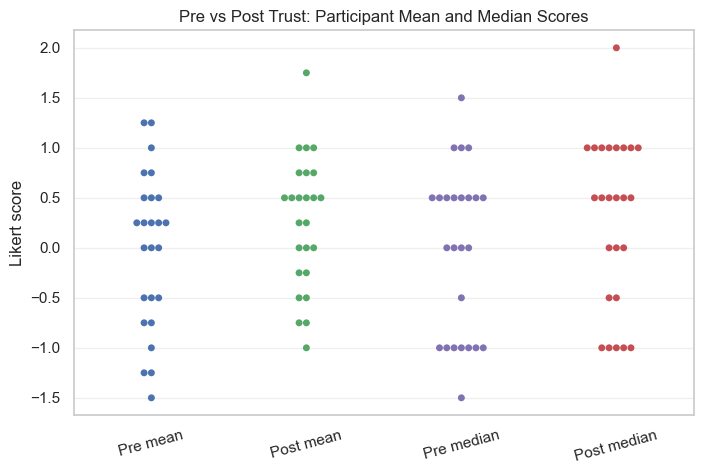

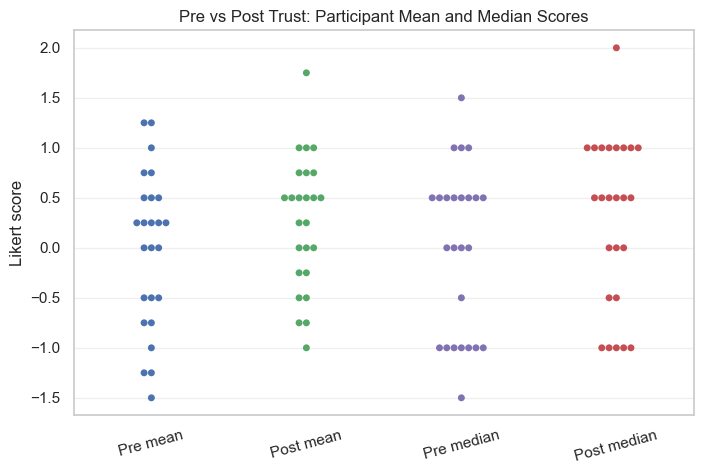

In [66]:
def plot_pre_post_trust_swarmplot(df, question_pairs, likert_scale, section="explanation_trust", ax=None):
    """Plot participant-level mean and median trust scores for pre and post as a swarm plot."""
    pairs = question_pairs[section]
    reverse_cols = ["Q00018","Q00032"] 
    participant_scores = pd.DataFrame(index=df.index)
    pre_cols = []
    post_cols = []

    for item, cols in pairs.items():
        pre_col = df[cols["pre"]].map(likert_scale)
        post_col = df[cols["post"]].map(likert_scale)
        
        if cols["pre"] in reverse_cols:
            pre_col = pre_col * -1
        if cols["post"] in reverse_cols:
            post_col = post_col * -1

        participant_scores[f"{item}_pre"] = pre_col
        participant_scores[f"{item}_post"] = post_col
        pre_cols.append(f"{item}_pre")
        post_cols.append(f"{item}_post")

    participant_scores["pre_mean"] = participant_scores[pre_cols].mean(axis=1, skipna=True)
    participant_scores["post_mean"] = participant_scores[post_cols].mean(axis=1, skipna=True)
    participant_scores["pre_median"] = participant_scores[pre_cols].median(axis=1, skipna=True)
    participant_scores["post_median"] = participant_scores[post_cols].median(axis=1, skipna=True)

    plot_data = participant_scores[
        ["pre_mean", "post_mean", "pre_median", "post_median"]
    ].rename(
        columns={
            "pre_mean": "Pre mean",
            "post_mean": "Post mean",
            "pre_median": "Pre median",
            "post_median": "Post median",
        }
    ).reset_index(drop=True)
    plot_data = plot_data.melt(var_name="Measure", value_name="Trust score").dropna()

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))
    else:
        fig = ax.figure

    sns.swarmplot(
        data=plot_data,
        x="Measure",
        y="Trust score",
        order=["Pre mean", "Post mean", "Pre median", "Post median"],
        ax=ax,
        palette=["#4C72B0", "#55A868", "#8172B2", "#C44E52"],
        size=5,
    )
    ax.set_title("Pre vs Post Trust: Participant Mean and Median Scores")
    ax.set_xlabel("")
    ax.set_ylabel("Likert score")
    ax.grid(axis="y", alpha=0.3)
    ax.tick_params(axis="x", rotation=15)

    return participant_scores, fig, ax


if 'df' in globals() and 'question_pairs' in globals() and 'likert_scale' in globals():
    trust_participant_scores, trust_fig, trust_ax = plot_pre_post_trust_swarmplot(
        df, question_pairs, likert_scale, section="explanation_trust"
    )
    display(trust_participant_scores[["pre_mean", "post_mean", "pre_median", "post_median"]].head())
    display(trust_fig)
else:
    print("Run the data-loading cells first, then rerun this cell to create the trust swarm plot.")